In [5]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
import os


def load_graph_csv(path):
    path = Path(path)

    with open(path, "r") as f:
        lines = f.readlines()

    voxel_count = [int(x) for x in lines[0].split(":", 1)[1].strip().split(",")]
    volume = [float(x) for x in lines[1].split(":", 1)[1].strip().split(",")]
    names = lines[2].split(":", 1)[1].strip().split(",")

    # adj matrix
    matrix = np.loadtxt(path, delimiter=",", skiprows=3)
    # if not connected we pick the largest component
    """
    Carefully consider how to handle missing edges and disconnected vertices, where
    they occur. (If the graph is split into multiple connected components you can focus on the
    largest one.) 
    """
    if not nx.is_connected(nx.from_numpy_array(matrix)):
        G = nx.from_numpy_array(matrix)
        largest_cc = max(nx.connected_components(G), key=len)
        matrix = matrix[np.ix_(list(largest_cc), list(largest_cc))]
        names = [names[i] for i in largest_cc]
        voxel_count = [voxel_count[i] for i in largest_cc]
        volume = [volume[i] for i in largest_cc]


    return {
        "matrix": matrix,
        "names": names,
        "voxel_count": voxel_count,
        "volume": volume,
    }

# plotting 
def plot_connectome(matrix, names, title="Connectome"):
    matrix = np.array(matrix)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # heatmap
    im = axes[0].imshow(matrix, interpolation="nearest", cmap="binary")
    axes[0].set_title(f"{title} - Adjacency Matrix")
    axes[0].set_xlabel("Region")
    axes[0].set_ylabel("Region")
    plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    #network graph
    G = nx.from_numpy_array(matrix)

    # shorter labels
    short_labels = {
        i: names[i].replace("_left", "_L").replace("_right", "_R")
        for i in range(len(names))
    }

    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_edges(G, pos, ax=axes[1], width=0.6, alpha=0.6)
    nx.draw_networkx_nodes(G, pos, ax=axes[1], node_size=80)
    nx.draw_networkx_labels(G, pos, labels=short_labels, ax=axes[1], font_size=6)

    axes[1].set_title(f"{title} - Network Graph")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()



In [6]:
files = []
connectomes_dir = Path("Task1Data/connectomes")
for file in os.listdir(connectomes_dir):
    if file.endswith(".csv"):
        files.append(connectomes_dir / file)
print(f"Found {len(files)} connectome files.")


Found 8 connectome files.


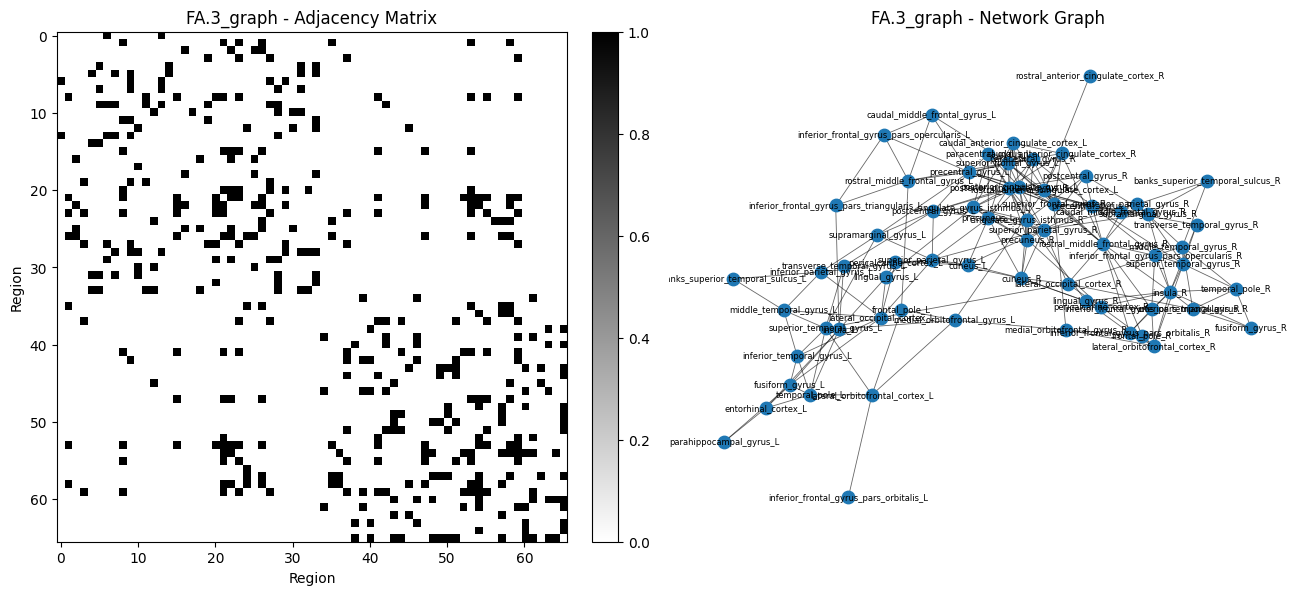

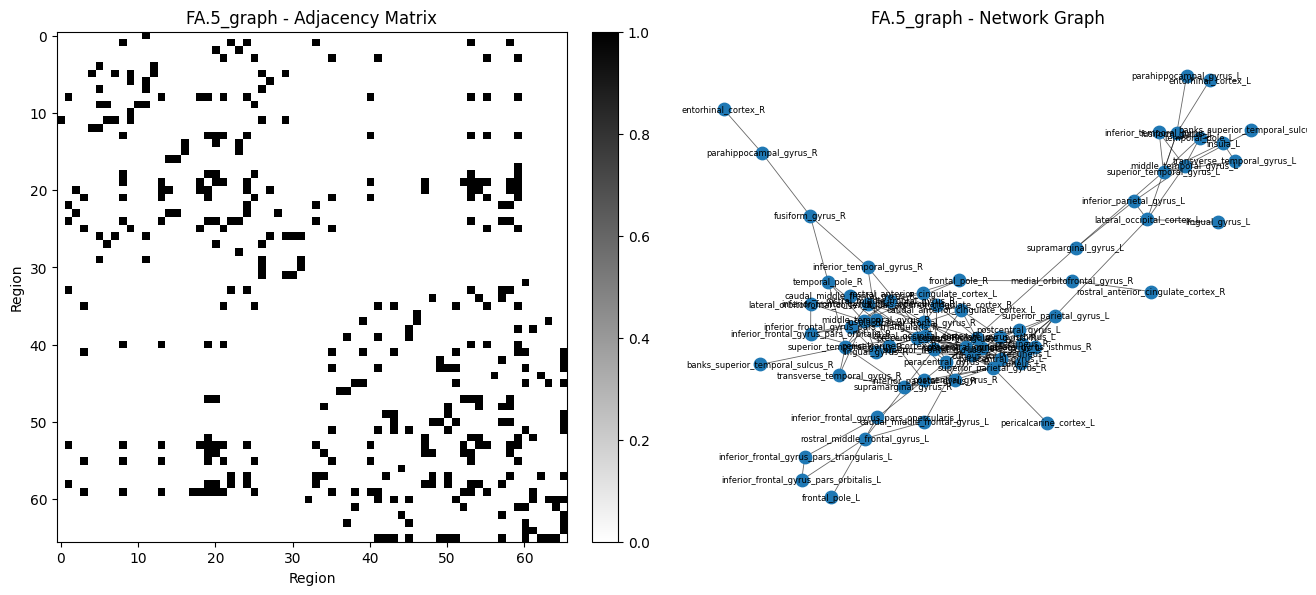

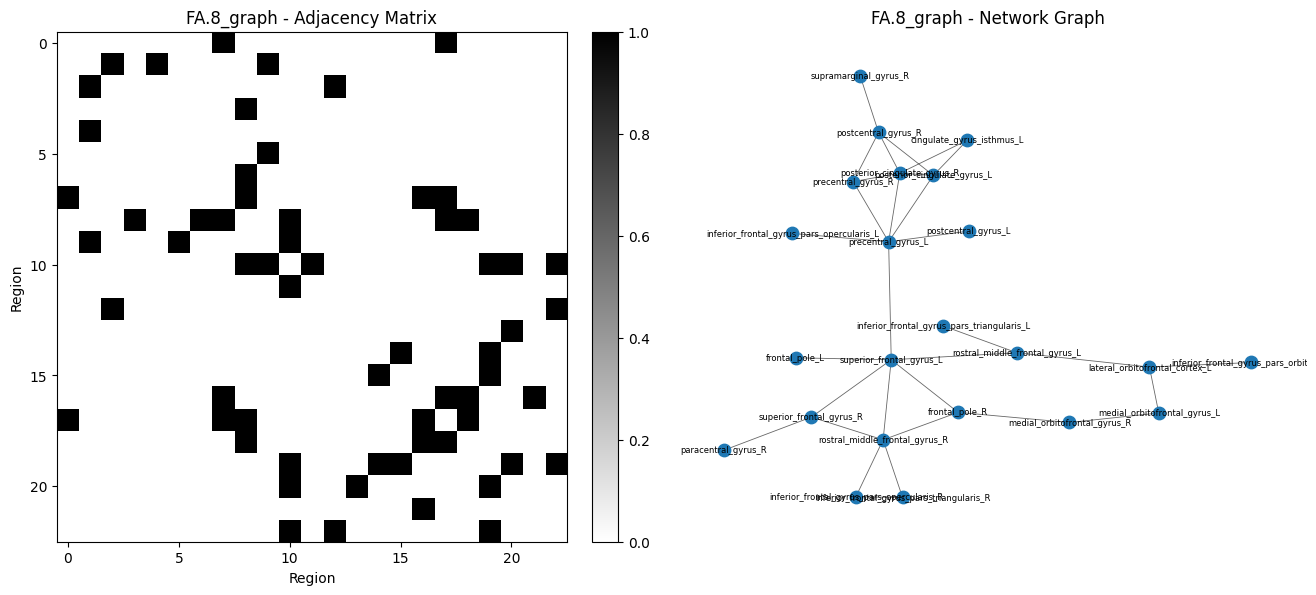

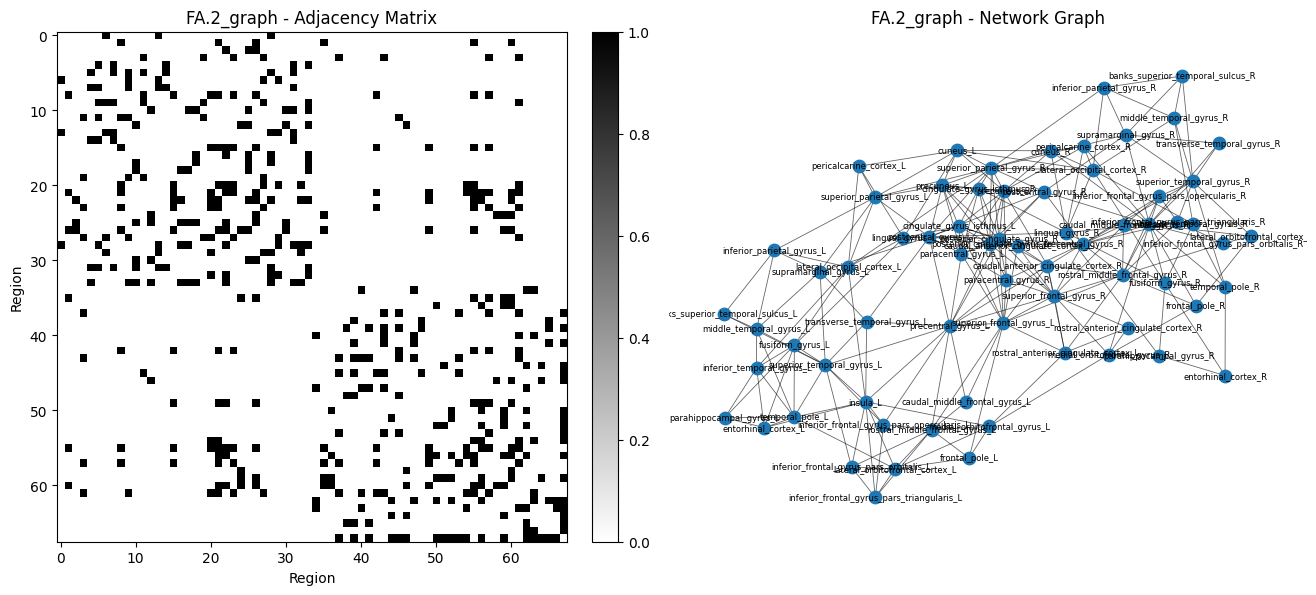

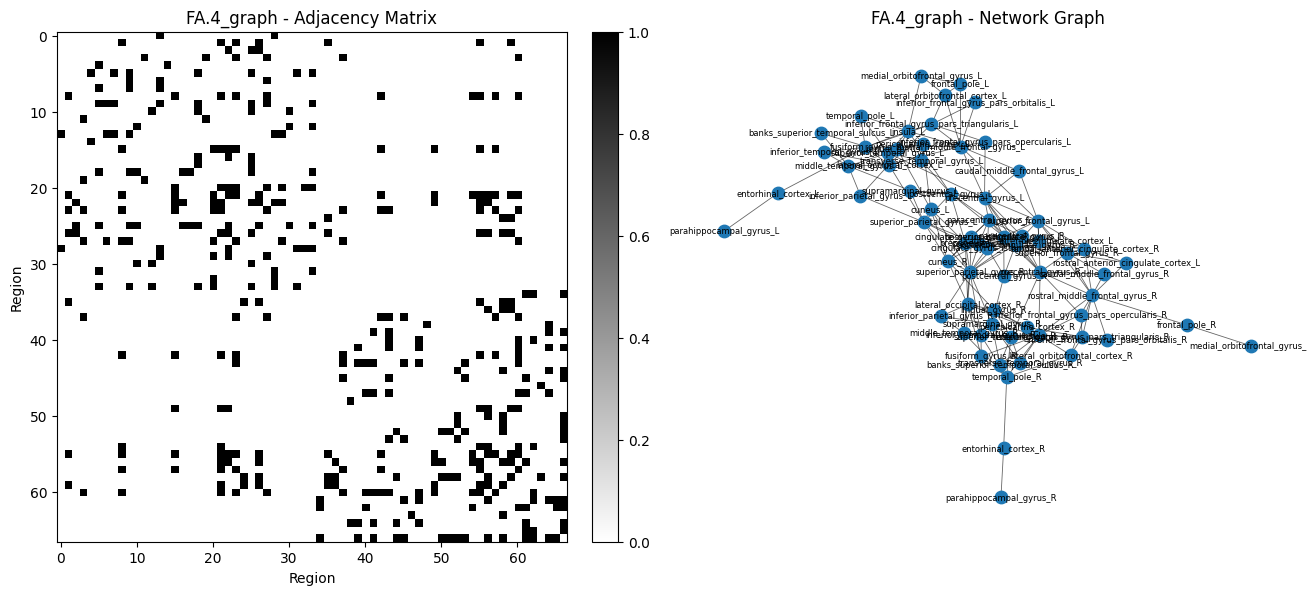

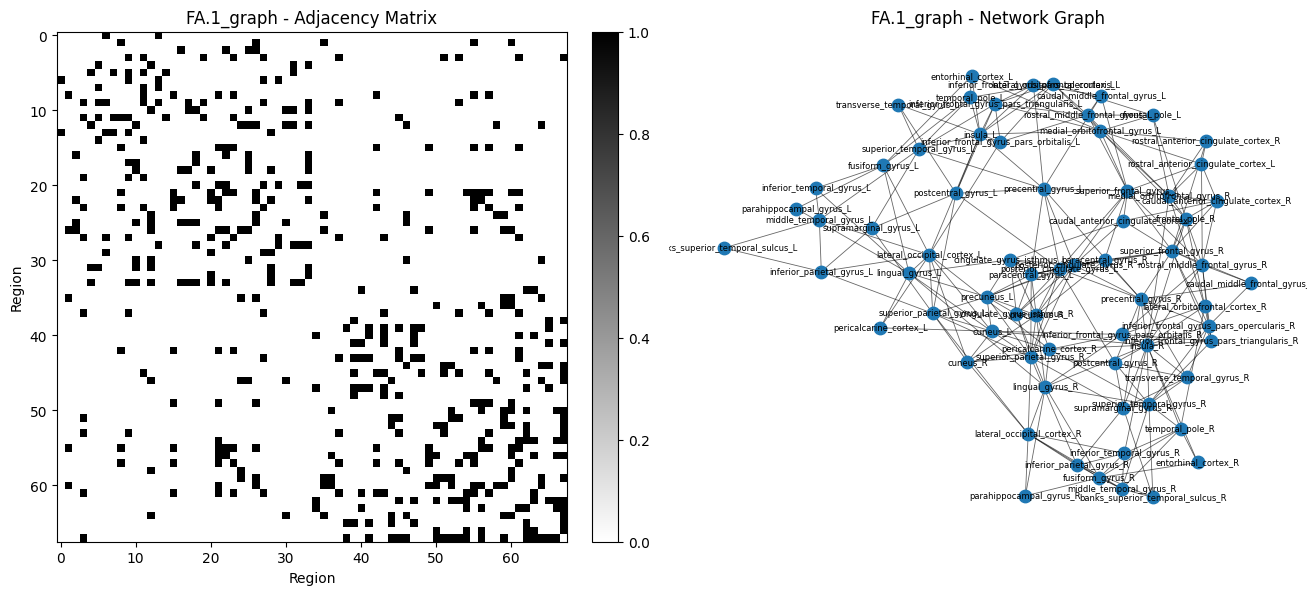

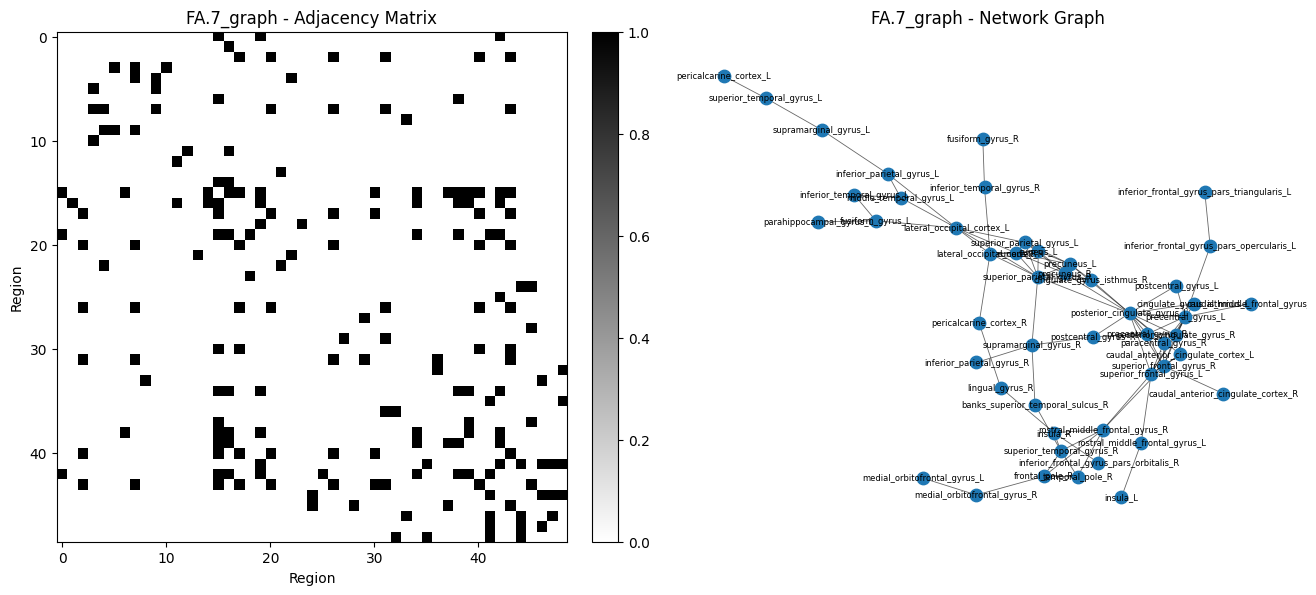

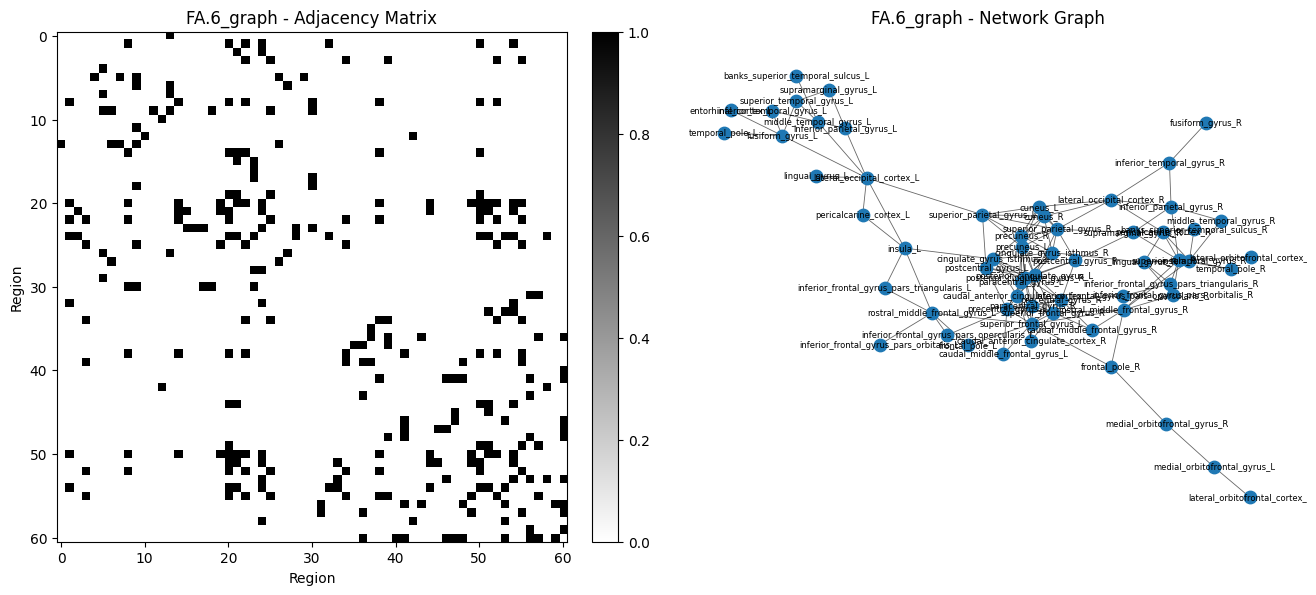

In [7]:

for file in files:
    data = load_graph_csv(file)
    plot_connectome(data["matrix"], data["names"], title=Path(file).stem)

# edge density and mean shortest path


In [8]:
# edge density
def edge_density(matrix):
    n = matrix.shape[0]
    possible_edges = n * (n - 1) / 2
    actual_edges = np.sum(matrix > 0) / 2
    return actual_edges / possible_edges

# mean shortest path
def mean_shortest_path(matrix):
    G = nx.from_numpy_array(matrix)
    return nx.average_shortest_path_length(G)

def efficiency(matrix):
    """
    Average path length: the mean shortest path length between 
    pairs of vertices (efficiency)
    """
    G = nx.from_numpy_array(matrix)
    return nx.global_efficiency(G)

def mean_clustering_coeff(matrix):
    G = nx.from_numpy_array(matrix)
    return nx.average_clustering(G)




file1 = files[0]
data = load_graph_csv(file1)
file1_mat = data["matrix"]
print(file1_mat)
print(f"Edge Density: {edge_density(file1_mat):.4f}")
print(f"Mean Shortest Path Length: {mean_shortest_path(file1_mat):.4f}")
print(f"Efficiency: {efficiency(file1_mat):.4f}")
print(f"Mean Clustering Coefficient: {mean_clustering_coeff(file1_mat):.4f}")


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 1. 1. 0.]]
Edge Density: 0.1012
Mean Shortest Path Length: 2.9478
Efficiency: 0.4131
Mean Clustering Coefficient: 0.4654


# Task 3 missing: Discuss the effects of varying the FA threshold on the graphs, and the reasons for them.